**Welcome to the Tutorial on neural or ocular speech tracking using TRFs with eelbrain boosting! Let's get started.**

*What is this about?* 
Eelbrain is a neuroscientific analysis toolbox for python. With it’s boosting class you can calculate temporal response functions (TRF). This Tutorial is going to walk you through this analysis. 

*What do I need?* 

This tutorial was written as a Jupyter Notebook. So you only need an a working python environment that includes all standard toolboxes as well as eelbrain to open it in make sure to also have the data_simulation.py script available in your environment. No data or anything is needed for this tutorial. If you want to perform the analysis with your own data, you’ll need the following: 

* The preprocessed data of at least two variables (e.g. EEG/MEG, Eye Tracking, Speech Envelope) (HEREs the tutorial for our standard preprocessing pipelines) 

* Temporal information about the experimental setup. In other words, you need information about the stimulus onset and duration. Usually, you can extract that information from the trigger data from the experiment. Check out subject_data files and experiment code so you can adjust the pipeline to fit the procedure. 

* A hypothesis. Make sure you understand the aim of your analysis before you proceed. 

*Where?* This Tutorial is for python. Since the calculation is quite powerful, we recommend you to run a full scale analysis on the SCC, especially once you’re ready to use your pipeline on all of the subjects. The tutorial will probably run on your local PC, some calculation might just take a few minutes. 

*Why?* TRF is one of our standard ways to measure ocular or neural speech tracking (besides coherence and temporal mutual information). As the name implies, a temporal response function measures the temporal dynamics between two variables, i.e. how the state of one variable (e.g. the speech envelope) now modulates the state of another variable (e.g. eye movements) later.  

*Who?* Questions on this topic can be addressed to any advanced member of the lab. We’re happy to help. This tutorial was written by Veronika. 

*What else:* Check our onboarding tutorial if some of the terms used in this introduction feel scary. Most of it will probably clarify. 

_______________________________________________________________________________________________________________________________________________________________________________________________________

If you want to start performing a TRF analysis, check your to do list first: Is your data preprocessed? Do you have the subject data from your experiment ready? Is your environment up and running, with eelbrain and mne as available toolboxes? If you can confidently answer with yes, let’s go. 

First, load your preprocessed data. This can be an mne object or just some arrays. Also, load your trigger data. Your trigger data should contain two things: the trigger values sent from the o_ptb and the corresponding time stamps in your data. Last but not least you will need the corresponding envelopes of the audio signal of your experiment. 

For the purpose of this tutorial, we'll use simulated data. Imagine it has already been preprocessed. Our setup is the following: we have EEG data, Eye Tracking data and an envelope from an audiobook. Let's see if we can get some tracking results!

In [1]:
#imports
import numpy as np
np.random.seed(42)
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
import eelbrain as eb
import matplotlib.pyplot as plt
from data_simulation import simulate_eeg_signal, simulate_gaze_path,simulate_audio_envelope

In [2]:
#data simulation
sample_rate = 200
audio_envelope = simulate_audio_envelope(duration=100, sample_rate=sample_rate)
raw_eeg, eeg_data = simulate_eeg_signal(envelope=audio_envelope, sample_rate=sample_rate, duration = 120, noise_level=0.3)
montage = mne.channels.make_standard_montage('easycap-M1')
raw_eeg.set_montage(montage)

eeg_df = raw_eeg.to_data_frame()

gaze_x, gaze_y = simulate_gaze_path(envelope=audio_envelope, duration=120, sample_rate=sample_rate, screen_width=1920, screen_height=1080, fixation_duration=30)

eye_df = pd.DataFrame({
    'Time': np.linspace(0, 120, 200 * 120),
    'Gaze_X': gaze_x,
    'Gaze_Y': gaze_y,
})



Creating RawArray with float64 data, n_channels=32, n_times=24000
    Range : 0 ... 23999 =      0.000 ...   119.995 secs
Ready.


Let's plot our data to look at it's shape. That's always a good idea before starting an analysis.

In [ ]:
plt.plot(eeg_data[0]) #plot one channel

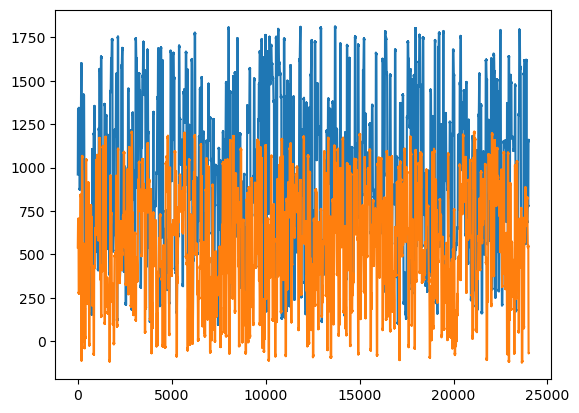

In [3]:
plt.plot(gaze_x)
plt.plot(gaze_y)

In [ ]:
plt.plot(audio_envelope)

Great, we have our data ready! Let's make one MNE object out of EEG and Eye Tracking data. The EEG data is already a MNE raw object (raw_eeg). MNE is a very useful toolbox for processing EEG/MEG data. You will see how useful during this tutorial, however it is strongly recommended to work through their documentation. You will find solutions there for lots of problems you might encounter somewhere down your analysis.

In [4]:
eye_ch_names = [col for col in eye_df.columns if col != 'Time']
eye_ch_types = ['bio'] * len(eye_ch_names)  #bio channels can be used for every physiological signal that's not brain 
eye_data = eye_df[eye_ch_names].to_numpy().T
eye_info = mne.create_info(ch_names=eye_ch_names, sfreq=200, ch_types=eye_ch_types)
raw_eye = mne.io.RawArray(eye_data, eye_info)


raw_eeg.add_channels([raw_eye])


Creating RawArray with float64 data, n_channels=2, n_times=24000
    Range : 0 ... 23999 =      0.000 ...   119.995 secs
Ready.


<RawArray | 34 x 24000 (120.0 s), ~6.3 MiB, data loaded>

Okay, perfect. Now, let's talk about triggers. Triggers are essential in time-based analysis. Without them you are lost, quite literally. You will have no chance to identify stimulation on- and offset in your data and thus, never know if the data your analyzing is actually a reaction to the stimulus (that is, if you are analysing brain or eye data that was really recorded during the audio book).

Usually, you design your experiment in a way it automatically gives you the right triggers at the right time. When you are working with MEG data from the SBDL you will have the convenience that the o_ptb communicates with the MEG and the MEG Eye Tracker and sends your triggers to both. If you are using other recording situations, you might have used a software for that, e.g. Lab Streaming Layer.

In any way, you should have triggers in the shape of indices from your data and trigger values that you can couple to a specific event. Let's make some triggers up.

In [5]:
trigger_timestamps = np.array([2000, 16476, 22000])
trigger_values = np.array([38, 52, 39])
trigger_dict = {
    'start' : 38,
    'in between' : 52,
    'end' : 39
}

OK cool, we now have trigger values and indices and we know what they mean. So trigger 38 marks the start of our experiment and 39 marks the end. 52 is a trigger in between, it has no meaning here but in a real dataset you might encounter lots of triggers that you might want to exclude when looking at events (e.g. a trigger for a turning Gabor patch). Let's double check if our triggers actually cover time stamps in our data!

In [6]:
for trigger in trigger_timestamps:
    if trigger in np.arange(len(raw_eeg.times)):
        print('Trigger valid!')
    else:
        print('Trigger not valid!')


Trigger valid!
Trigger valid!
Trigger valid!


Nice, all of our trigger time stamps cover real times in the data. Perfect. Let's mark our triggers in the data. We use the annotation function of mne for that. This function requires the time stamps in seconds, not in samples, so we devide the trigger stamps by our sampling frequency.

In [7]:
triggers_in_seconds = [trigger/sample_rate for trigger in trigger_timestamps]
annotations = mne.Annotations(triggers_in_seconds, duration=0, description='T')
raw_eeg.set_annotations(annotations)

<RawArray | 34 x 24000 (120.0 s), ~6.3 MiB, data loaded>

If we plot the data now, we see that it has three annotations marked with T for triggers.

In [8]:
raw_eeg.plot(scalings = 'auto')

Using qt as 2D backend.


Important: if you're recordings are from different devices, which is almost always the case, you will have to make sure the triggers are 100% aligned. Even few milliseconds can kill your effects. So to be sure, you can use the mne-raw realign function. If you have events in both data streams, you can do it like this:

In [ ]:
events_eeg = mne.read_events_from_annotations(raw_eeg)
events_eye = mne.read_events_from_annotations(raw_eeg)
mne.preprocessing.realign_raw(raw_eeg, raw_eye, events_eeg, events_eye)

For now, let's assume there's no mismatch and we can continue with the events by our triggers.

We now want to mark start and end of our trial. To do that we use our start and end trigger to add annotations. 

In [9]:
start_trigger = [trigger for index, trigger in enumerate(trigger_timestamps) if trigger_values[index] == 38]
end_trigger = [trigger for index, trigger in enumerate(trigger_timestamps) if trigger_values[index] == 39] #get the trigger index for the end and start trigger
start_sec = start_trigger[0]/200 #transform in seconds
end_sec = end_trigger[0]/200
event_annotations = mne.Annotations([start_sec, end_sec], duration=0, description=['start','end']) #annotate onset trigger for trials as events
raw_eeg.set_annotations(event_annotations)

raw_eeg.plot(scalings='auto')

In [10]:
start_sec

10.0

You can see on the plot now that there are two markers, one for the start of the event, one for the end. The next step is to crop the data accordingly, since we are only interested in the stimulation part. MNE allows you to mark annotations as events and then use those events to cut the data in so called epochs. In the processing of time series data, epoching or cutting the data is a crucial step. We usually do not want to use all our data, since it contains recordings between trials etc.. So epoching is essential, and the time point of cutting depends on what you want to analyze. Here, we want the data that is recorded from the start of the trial until the end of the trial, corresponding to the period when the participant was listening to the audio. You can find more about MNE epochs in other tutorials, however here we will just crop the data in this tutorial.

We use the length of the envelope to do this. Of course, you could in this case also use the end trigger. But sometimes we do not have a trigger to mark the end of the trial. Please note that often, the audio envelope will have another sampling frequency and you will have to resample before doing this! Since we already have the same sampling frequency, we know that 1 sample in the envelope is the same length as in the data.

In [11]:
end_sample = start_trigger[0] + len(audio_envelope)
end_sec_through_envelope = end_sample/200
raw_cropped = raw_eeg.crop(tmin=start_sec, tmax=end_sec_through_envelope-1/200)

The result is a short piece of data that should exactly match the length of our envelope. Let's check this.

In [12]:
raw_cropped.n_times == len(audio_envelope)

True

Perfect. Note that, while it is quite easy here, epoching your data become more challenging when you have several conditions, randomized audios etc. You will have to make sure that you crop the data according to the right envelope. You usually do this by using the information about the randomization etc. from your subject_data file.

So now we have an envelope and the cropped eeg and eye tracking data to match the length and the time of presentation. We're ready to calculate some TRFs!

**Performing the boosting**

Now we are finally ready to calculate some TRFs! We use eelbrain boosting for that, which is a python toolbox that will luckily handle the calculation of the temporal response function for us - which is the predicted signal and the correlation between predicted and actual signal. What we need to do is bring the data in the right shape for the toolbox to handle it. The toolbox has its own kind of variables. Let's look at it step by step.

First, we transform the EEG data. To make an eelbrain variable out of neural time series data, we need a variable for the sensor and time dimensions first.

In [13]:
def eelbrain_time_dim(raw_cropped):
        return eb.UTS(
            tmin= raw_cropped.times.min(),
            tstep=1. / raw_cropped.info['sfreq'],
            nsamples= raw_cropped.times.shape[0]
        )

def eelbrain_channel_dim(raw_cropped):
        eeg_channel_names = mne.pick_types(raw_cropped.info, eeg=True)
        names = [raw_cropped.ch_names[i] for i in eeg_channel_names]

        eeg_channel_locations = [raw_cropped.info['chs'][i]['loc'][:3] for i in eeg_channel_names]

        return eb.Sensor(eeg_channel_locations, names)

eelbrain_time = eelbrain_time_dim(raw_cropped)
eelbrain_channel = eelbrain_channel_dim(raw_cropped)

Now, we can create our EEG data variable.

In [14]:
def eelbrain_eeg_data(raw_cropped):
        eeg_data = raw_cropped.copy().load_data().pick('eeg', exclude=raw_cropped.info['bads']).get_data()
        return eb.NDVar(
            eeg_data,
            (eelbrain_channel, eelbrain_time),
            name='brain'
        )

eb_brain = eelbrain_eeg_data(raw_cropped)

Next is the eye tracking variable. We can use the time variable from above, because EEG, envelope and Eye Tracking data is adjusted to the same time frame.

In [15]:
def eelbrain_eyetracker_data(raw_cropped):
        eye_data = raw_cropped.get_data(['Gaze_X', 'Gaze_Y'])
        return eb.NDVar(
            eye_data[:, :],
            (eb.Categorial('eyes', ['Gaze_X', 'Gaze_y']), eelbrain_time)
        )

eb_eye = eelbrain_eyetracker_data(raw_cropped)

And last but not least, the envelope.

In [16]:
def eelbrain_envelope_data(audio_envelope):
        envelope_tmp_data = audio_envelope
        return eb.NDVar(envelope_tmp_data[:],
                              (eelbrain_time, ),
                              name='envelope')

eb_env = eelbrain_envelope_data(audio_envelope)

Ok, now it's getting really interesting! We will perform our boosting analysis!

In the boosting analysis, we define several key parameters. We strongly recommend reviewing the Eelbrain documentation to fully understand their roles and how they impact your model.

In our example, we set the number of partitions to 5. This means that our already epoched dataset is further divided into 5 partitions (or folds). Each partition is treated like an independent dataset. This step is important because Temporal Response Functions (TRFs) are data-driven models, and having multiple, separate partitions allows us to perform cross-validation, which is essential for evaluating how well the model generalizes.

The parameters tstart and tstop define the temporal window over which the model should learn the mapping between the stimulus and the brain response. For instance, with tstart=-0.4 and tstop=0.8, we are asking the model to evaluate how each time point in the stimulus predicts the brain response from 400 ms before to 800 ms after that stimulus time point. This full time-lag window slides across the entire duration of the data within each partition.

You can think of this process as similar to moving a sliding window across the stimulus, assessing the brain's or eyes' response to each stimulus time point within the defined window. In essence, it helps identify the time course of the brain's response to specific features in the stimulus.

Since we want to have a smooth predicted signal even though we calculate single values for different time points, we use a gaussian kernel to smooth the samples of the predicted signal. The width of this curve is defined by the basis parameter, so in our case 10ms. The smaller this parameter, the less noisy our estimated signal. This is a bit technical and hard to imagine, but something you will grow an intuition for over time.

During cross-validation, we iteratively train the model on a subset of the partitions (e.g., partitions 1–4) and test it on the remaining partition (e.g., partition 5). This is repeated across all combinations (e.g., training on 1,2,3,5 and testing on 4, etc.), allowing for a robust estimation of model performance.

In [17]:
tstart = -.4
tstop = .8 
partitions = 5
basis = 0.01
boosting_list_for_df = []

for list_index, cur_data in enumerate([eb_eye, eb_brain]): #perform TRF analysis seperately for eye and brain data
                        cur_info = {    #meta info we might need later
                                'experiment' : 'audio stimulation',
                                'subject_id' : '123testsubject'
                        }
                        if list_index == 0: #save the right data type so later we know if it's neural or ocular tracking
                            cur_info['data_type'] = 'eye_tracker'
                        elif list_index == 1:
                            cur_info['data_type'] = 'eeg'  
                        cur_info['boosting_results'] = eb.boosting( #this is where the magic happens
                                    x=eb_env,
                                    y=cur_data,
                                    tstart=tstart,
                                    tstop=tstop,
                                    basis=basis,
                                    partitions=partitions,
                                    test=1
                                )

                        boosting_list_for_df.append(cur_info)

Channels marked as bad:
none


Exciting, we have some results! You might have noticed we added some artificial metadata to the results dataframe. This is important because later on you want to match your results to the conditions, compare between subjects etc.
Let's have a look at the results now.

In [18]:
results_df = pd.DataFrame(boosting_list_for_df)
print(results_df)

          experiment      subject_id    data_type  \
0  audio stimulation  123testsubject  eye_tracker   
1  audio stimulation  123testsubject          eeg   

                                    boosting_results  
0  <boosting None ~ envelope, -0.4 - 0.8, basis=0...  
1  <boosting brain ~ envelope, -0.4 - 0.8, basis=...  


You can see a column named boosting results here, next to all our added metainfo. Let's look into the results.

In [19]:
for idx, dictt in enumerate(boosting_list_for_df):
    if boosting_list_for_df[idx]['data_type'] == 'eye_tracker':
        ocular_rescaled = boosting_list_for_df[idx]['boosting_results'].h_scaled
        predicted_time_ocular = boosting_list_for_df[idx]['boosting_results'].h_time
        TRF_ocular = boosting_list_for_df[idx]['boosting_results'].h
        ocular_speech_tracking_rank = boosting_list_for_df[idx]['boosting_results'].r_rank
        ocular_speech_tracking = boosting_list_for_df[idx]['boosting_results'].r
    elif boosting_list_for_df[idx]['data_type'] == 'eeg':
        neural_rescaled = boosting_list_for_df[idx]['boosting_results'].h_scaled
        predicted_time_neural = boosting_list_for_df[idx]['boosting_results'].h_time
        TRF_neural = boosting_list_for_df[idx]['boosting_results'].h
        neural_speech_tracking_rank = boosting_list_for_df[idx]['boosting_results'].r_rank
        neural_speech_tracking = boosting_list_for_df[idx]['boosting_results'].r

As you can see, boosting_results has lots of interesting properties. You can extract your TRF (h) and your TRF scaled based on your outcome variable (h_scaled) from it, as well as the correlation between predicted and actual signal (r_rank (spearman) or r (pearson)). This correlation is our measure for ocular and neural speech tracking. Let's do some plots to investigate our results.

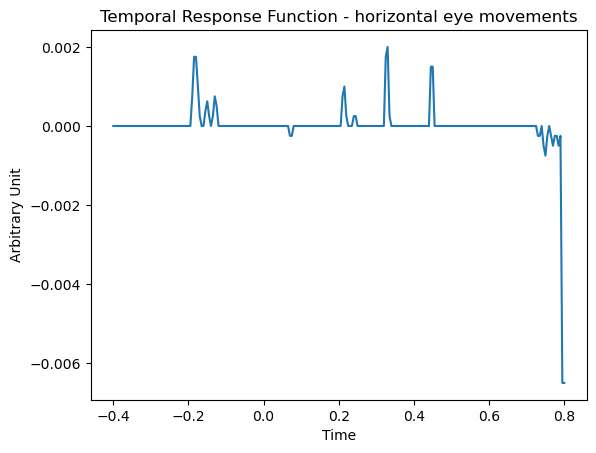

In [20]:
fig = plt.plot(predicted_time_ocular,TRF_ocular.get_data()[0])

plt.title("Temporal Response Function - horizontal eye movements")
plt.ylabel("Arbitrary Unit")
plt.xlabel("Time")
plt.show()

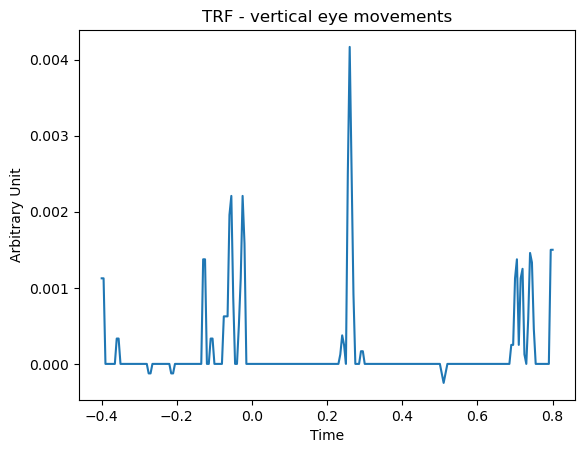

In [21]:
fig = plt.plot(predicted_time_ocular,TRF_ocular.get_data()[1])

plt.title("TRF - vertical eye movements")
plt.ylabel("Arbitrary Unit")
plt.xlabel("Time")
plt.show()

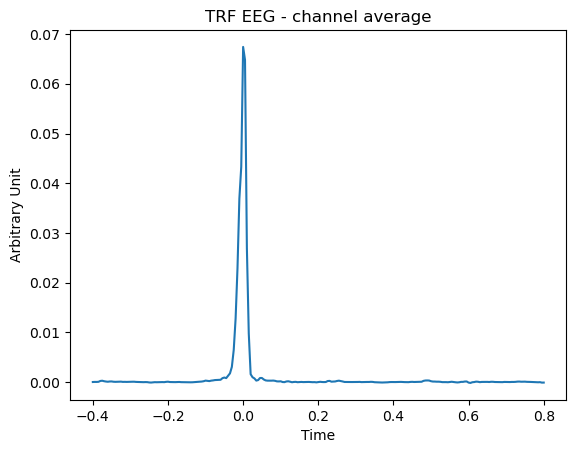

In [22]:
fig = plt.plot(predicted_time_neural,np.mean(TRF_neural.get_data(), axis=0))

plt.title("TRF EEG - channel average")
plt.ylabel("Arbitrary Unit")
plt.xlabel("Time")
plt.show()

Okay, so we see that the function captures almost no temporal dynamics for the eye movements, especially not the horizontal ones. There seems to be more going on for the neural data, but still the function oscillates around zero and doesn't seem to be super systematic. Let's see what the predicted signal looks like.

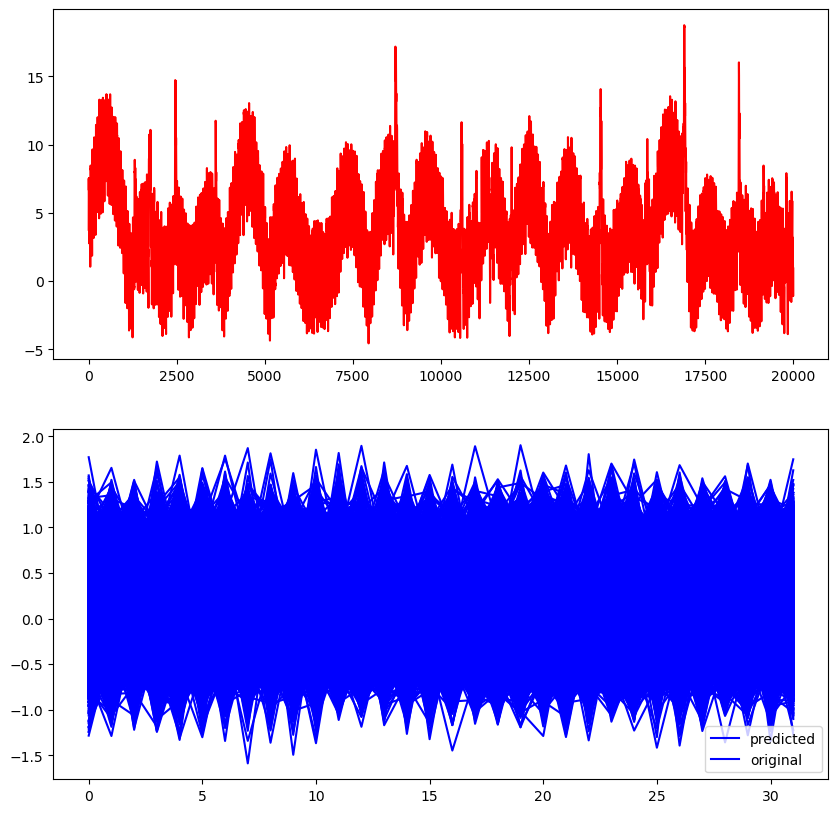

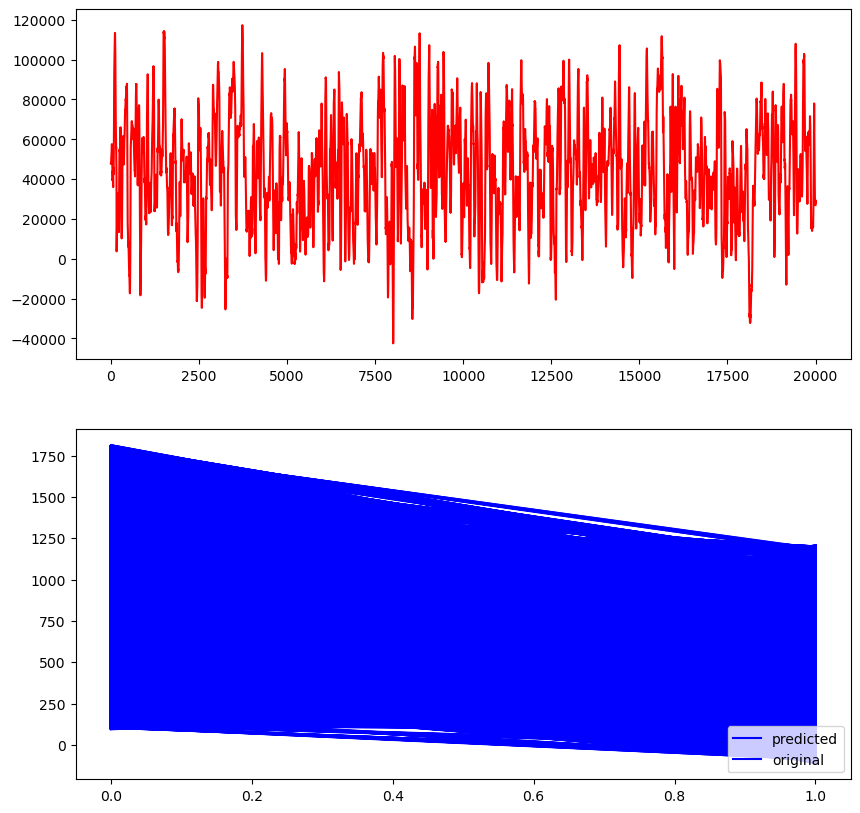

In [23]:
y_pred_eeg = eb.convolve(neural_rescaled, eb_brain) #calculate a predicted signal by convoluting the original data and the TRF
y_pred_eye = eb.convolve(ocular_rescaled, eb_eye) 

fig, ax = plt.subplots(2, 1, figsize=(10, 10)) 
ax[0].plot(y_pred_eeg.get_data(), color='red')
ax[1].plot(eb_brain.get_data(), color='blue')
plt.legend(["predicted","original"], loc="lower right")

fig, ax = plt.subplots(2, 1, figsize=(10, 10)) 
ax[0].plot(y_pred_eye.get_data(), color='red')
ax[1].plot(eb_eye.get_data(), color='blue')
plt.legend(["predicted","original"], loc="lower right")

It doesn't look too similar, right? What does the correlation tell us?


Note: We use both, rank and spearman here. It is debatable which one is more accurately capturing the relation and it also depends on what kind of connection your expect. Usually, since we expect a linear realtionship, using pearson r is fine.

In [24]:
print(np.mean(ocular_speech_tracking.get_data()[0])) #x data
print(np.mean(ocular_speech_tracking.get_data()[1])) #y data
print(np.mean(neural_speech_tracking.get_data())) #averaged over channels!

-0.05970505205922843
0.0471152542786789
0.32415551961271305


In [25]:
print(np.mean(ocular_speech_tracking_rank.get_data()[0])) #x data
print(np.mean(ocular_speech_tracking_rank.get_data()[1])) #y data
print(np.mean(neural_speech_tracking_rank.get_data())) #averaged over channels!

-0.05953529222681292
0.05897723388292577
0.30422086180298963


Oh well, those are small values - how can we interpret them? Best we look at other literature to find out more. Note that we can ignore the direction of the relationship here. Right now we are only interested in whether we can use the envelope to predict the neural/eye data.

If we look at the research of Gehmacher et al. (2024), we see that small values are expected! The size of the horizontal ocular tracking could represent an effect. However, the values for the neural speech tracking and the vertical eye movements are small, they will most likely not represent an effect. Also, keep in mind that we simulated the data randomly, so we also don't expect a connection. 

We now have multiple options to evaluate our results. Let's look at what eelbrain offers us.

-0.0031974633330198454
0.0021308851083391422


(array([1., 1., 3., 1., 0., 1., 2., 2., 2., 2., 2., 4., 6., 2., 3.]),
 array([0.09888598, 0.09954712, 0.10020826, 0.1008694 , 0.10153055,
        0.10219169, 0.10285283, 0.10351397, 0.10417512, 0.10483626,
        0.1054974 , 0.10615854, 0.10681969, 0.10748083, 0.10814197,
        0.10880311]),
 <BarContainer object of 15 artists>)

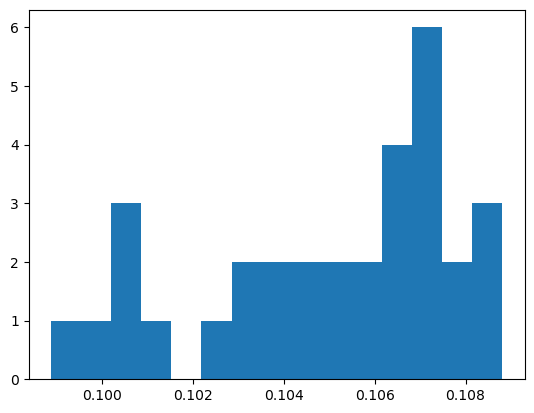

In [26]:
for idx, dictt in enumerate(boosting_list_for_df):
    if boosting_list_for_df[idx]['data_type'] == 'eye_tracker':
        ocular_explained = boosting_list_for_df[idx]['boosting_results'].proportion_explained
    elif boosting_list_for_df[idx]['data_type'] == 'eeg':
        neural_explained = boosting_list_for_df[idx]['boosting_results'].proportion_explained

print(ocular_explained.get_data()[0])
print(ocular_explained.get_data()[1])

plt.hist(neural_explained.get_data(), bins=15)

Even thought the explained proportion doesnt 100% correspond to the explained variance, we can still interpret it in a similar way. The values are really low. For the neural tracking, they aggregate around 0. We see that our model (that is the TRF based on the envelope) is not working so well in predicting the signal in this case. That means that there is not too much information about the envelope in the neural/ocular data, thus, we do not observe ocular or neural speech tracking here.

There are multiple ways we can now further work with the boosting results. Of course, you could use the correlation per channel/movement direction as dependent variable in statistical models. For example if you want to observe group or condition differences. You could also build control models, e.g. with a simulated envelope, with envelopes that don't match the heard stimuli, with resting state data etc. and then test your results against each other. As you can see, there are a lot of options, which is nice but can also be dangerously close to p-hacking. This is why it's best you decide for one strategy that matches your hypothesis and stick to that. Feel free to discuss this topic with any member of the lab.